# Deep Deterministic Policy Gradient

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from ddpg.ddpg import ddpg_trainer
from IPython.display import HTML, clear_output, display
import tensorflow as tf
#print(tf.__version__)
#import keras
#print(keras.__version__)

In [2]:
# pendulum parameters
pendulum_model_name = 'rail'
# rail pendulum
if pendulum_model_name == 'rail':
    mass = 0.06 
    length = 0.1
    damping = 0.0004
    torque_limit = 0.02
    coulomb_fric = 0.0
# dfki pendulum
elif pendulum_model_name == 'dfki':  
    mass = 0.57288
    length = 0.5
    damping = 0.15
    torque_limit = 1.5
    coulomb_fric = 0.02
else:
    raise Exception(f"Pendulum model {pendulum_model_name} not implemented")


inertia = mass*length**2

gravity = 9.81


# environment parameters
dt = 0.05 # changed from 0.01
integrator = "runge_kutta"
max_steps = 200
reward_type = "combined_reward"
target = [np.pi, 0]
target_epsilon = [0.1, 0.1] # changed from 0.05
random_init = "everywhere"

# training parameters
n_episodes = 10
batch_size = 64
validate_every = 10
validation_reps = 10
validation_limit = 0 
train_every_steps = 1
state_representation = 3
replay_buffer_size = 50_000 # changed from 50_000

actor = tf.keras.models.load_model("log_data/ddpg_training/actor.keras")
#actor.compile(optimizer="adam", loss="mse")
critic = tf.keras.models.load_model("log_data/ddpg_training/critic.keras")
#critic.compile(optimizer="adam", loss="mse")
actor = None  # use default agent
critic = None  # use default critic
discount = 0.99
actor_lr = 0.0005
critic_lr = 0.001 
tau = 0.005 

In [3]:
save_dir = "log_data/ddpg_training"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

print(f"Using pendulum model from {pendulum_model_name}.")


trainer = ddpg_trainer(batch_size=batch_size,
                       validate_every=validate_every,
                       validation_reps=validation_reps,
                       train_every_steps=train_every_steps)

trainer.init_pendulum(mass=mass,
                      length=length,
                      inertia=inertia,
                      damping=damping,
                      coulomb_friction=coulomb_fric,
                      gravity=gravity,
                      torque_limit=torque_limit)

trainer.init_environment(dt=dt,
                         integrator=integrator,
                         max_steps=max_steps,
                         reward_type=reward_type,
                         state_representation=state_representation,
                         validation_limit=validation_limit,
                         target=target,
                         state_target_epsilon=target_epsilon,
                         random_init=random_init,)

trainer.init_agent(replay_buffer_size=replay_buffer_size,
                   actor=actor,
                   critic=critic,
                   discount=discount,
                   actor_lr=actor_lr,
                   critic_lr=critic_lr,
                   tau=tau)

rewards, actor_losses, critic_losses = trainer.train(n_episodes=n_episodes,
                                                     verbose=True)


trainer.save(save_dir)

Using pendulum model from rail.


/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         64 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │        544 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │         64 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     65,792 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        257 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,361 (325.63 KB)

 Trainable params: 83,361 (325.63 KB)

 Non-trainable params: 0 (0.00 B)

None
Episode: 0, Steps: 199, Reward: -2000, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [-0.07252436  0.35581318], Success: False
Episode: 1, Steps: 199, Reward: -1906.95, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [ 0.022181  -0.9302513], Success: False
Episode: 2, Steps: 199, Reward: -2000, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [ 0.01681869 -0.22566272], Success: False
Episode: 3, Steps: 199, Reward: -1962.21, Actor Loss: 1606.8948974609375, Critic Loss: 1539.3984375, Final State: [0.08008689 0.9182073 ], Success: False
Episode: 4, Steps: 199, Reward: -1960.71, Actor Loss: 3086.949462890625, Critic Loss: 118.58499908447266, Final State: [ 0.05886109 -0.11248752], Success: False
Episode: 5, Steps: 199, Reward: -1934.13, Actor Loss: 4415.9267578125, Critic Loss: 87.18881225585938, Final State: [-0.13290891  0.29528454], Success: False
Episode: 6, Steps: 199, Reward: -1960.75, Actor Loss: 5983.3916015625, Critic Loss: 101.78579711914062, Final State: [0.1693259  0.446

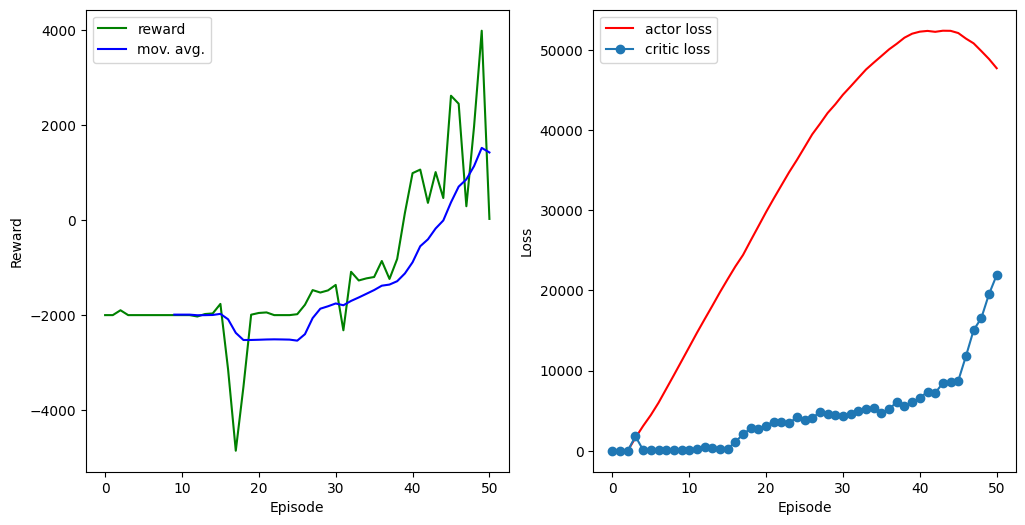

In [4]:
# plotting
MA_WINDOW = 10
ma_rewards = np.convolve(rewards, np.ones(MA_WINDOW)/MA_WINDOW, mode='valid')
episodes = np.arange(0, len(rewards))
ma_episodes = np.arange(len(rewards)-len(ma_rewards), len(rewards))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Reward, per episode and moving average
ax[0].plot(episodes, rewards, '-g', label='reward')
ax[0].plot(ma_episodes, ma_rewards, '-b', label='mov. avg.')
ax[0].set_xlabel('Episode')
ax[0].set_ylabel('Reward')
ax[0].legend()

ax[1].plot(actor_losses, '-r', label='actor loss')
ax[1].plot(critic_losses, '-o', label='critic loss')
ax[1].set_xlabel('Episode')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pendulum_plant.pendulum_plantzeroRPC import PendulumPlant
from pendulum_plant.simulation import Simulator
from ddpg.ddpg_controller import ddpg_controller


# Simulation using trained model

Final torque: 0.0036263312213122845


2025-07-04 14:20:33.640315: W tensorflow/c/c_api.cc:300] Operation '{name:'AssignVariableOp_17' id:273 op device:{requested: '/device:CPU:0', assigned: ''} def:{{{node AssignVariableOp_17}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false, _device="/device:CPU:0"](kernel_8, Identity_17)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
/opt/homebrew/lib/python3.10/site-packages/keras/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-07-04 14:20:33.659118: W tensorflow/c/c_api.cc:300] Operation '{name:'tf.math.multiply_1_2/Mul' id:290 op device:{requested: '', assigned: ''} def:{{{node tf.math.multiply_1_2/M

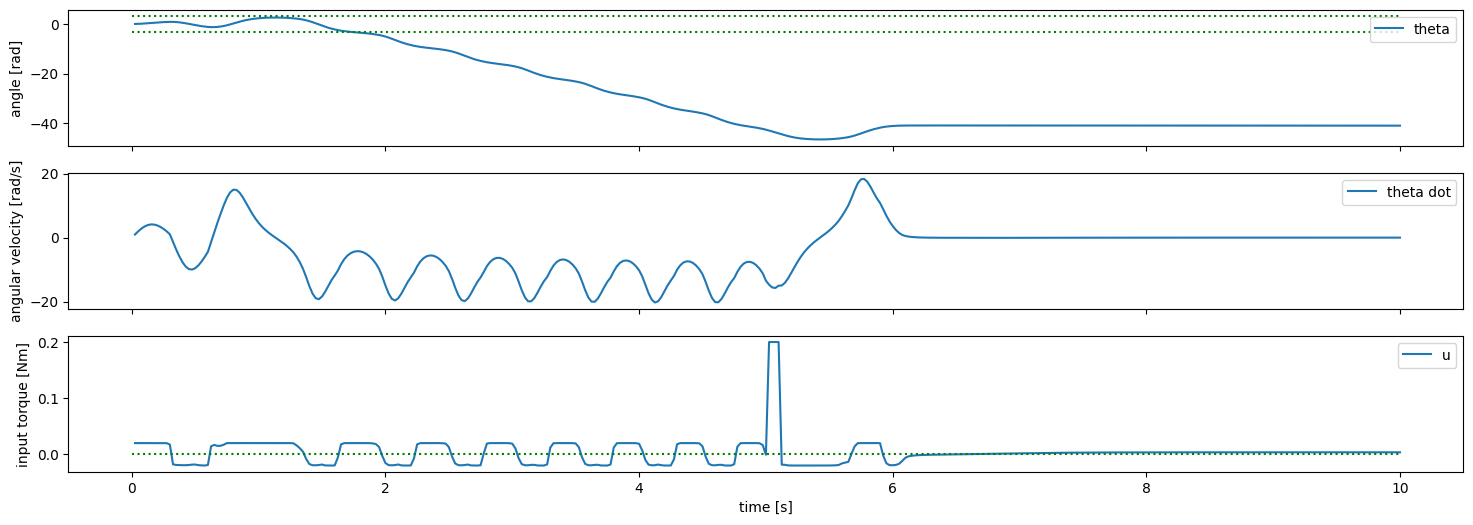

In [ ]:


mass = 0.06 
length = 0.1
damping = 0.0004
torque_limit = 0.02
coulomb_fric = 0.0
#mass = 0.06
#length = 0.1
#damping = 0.0004
#gravity = 9.81
#coulomb_fric = 0.02
#torque_limit = 0.01
#inertia = mass*length*length
inertia = mass*length**2

gravity = 9.81

dt = 0.025
t_final = 10.0
animate = False
pendulum = PendulumPlant(mass=mass,
                         length=length,
                         damping=damping,
                         gravity=gravity,
                         #coulomb_fric=coulomb_fric,
                         inertia=inertia,
                         torque_limit=torque_limit)


#model_path = "data_models/ddpg_model/actor"
model_path = "log_data/ddpg_training/actor.keras"
#model_path = "log_data/ddpg_training_rail_04tl_08dp/actor"

controller = ddpg_controller(model_path=model_path,
                             torque_limit=torque_limit,
                             state_representation=3)


sim = Simulator(plant=pendulum)

if animate:
  T, X, U = sim.simulate_and_animate(t0=0.0,
                                    x0=[-0.1, 0.0],
                                    tf=t_final,
                                    dt=dt,
                                    controller=controller,
                                    integrator="runge_kutta",
                                    save_video=True,
                                    video_name="video.mp4")
  video_html = HTML("""
  <video width="640" height="480" controls>
    <source src="video.mp4" type="video/mp4">
  </video>
  """)
  display(video_html)
  plt.close()
else:
  T, X, U = sim.simulate(t0=0.0,
                        x0=[-0.1, -0.1],
                        tf=t_final,
                        dt=dt,
                        controller=controller,
                        integrator="runge_kutta", push_torque=0.2)

fig, ax = plt.subplots(3, 1, figsize=(18, 6), sharex="all")
print(f"Final torque: {U[-1]}")
ax[0].plot(T, np.asarray(X).T[0], label="theta")
#theta_wrapped = (np.asarray(X).T[0] + np.pi) % (2 * np.pi) - np.pi
#ax[0].plot(T, theta_wrapped, label="theta")
ax[0].hlines(y=[-np.pi, np.pi], xmin=0, xmax = t_final, linestyles = ':', colors='g')
ax[0].set_ylabel("angle [rad]")
ax[0].legend(loc="best")
ax[1].plot(T, np.asarray(X).T[1], label="theta dot")
ax[1].set_ylabel("angular velocity [rad/s]")
ax[1].legend(loc="best")
ax[2].plot(T, np.asarray(U).flatten(), label="u")
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("input torque [Nm]")
ax[2].hlines(y=0, xmin=0, xmax=t_final, linestyles = ':', colors='g')
ax[2].legend(loc="best")
plt.show()



In [5]:
tf = 5 # Final time (s)
dt = 0.01 # Time step (s)
Treal_es, Xreal_es, Ureal_es, Ureal_es_des, vod_filepath = pendulum.run_on_hardware_hash(tf, dt, controller=controller) 

# Measured Position
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[0])
plt.xlabel("Time (s)") 
plt.ylabel("Position (rad)")
plt.title("Position (rad) vs Time (s)")
plt.show()

# Measured Velocity
plt.figure
plt.plot(Treal_es, np.asarray(Xreal_es).T[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (rad/s)")
plt.title("Velocity (rad/s) vs Time (s)")
plt.show()

# Measured Torque
plt.figure
plt.plot(Treal_es, Ureal_es)
plt.plot(Treal_es, Ureal_es_des)
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Torque (Nm) vs Time (s)")
plt.show()

# Export the data to csv file
measured_csv_data_es = np.array([Treal_es, np.asarray(Xreal_es).T[0], np.asarray(Xreal_es).T[1],Ureal_es]).T
np.savetxt("es_measured_data_es.csv", measured_csv_data_es, delimiter=',', header="time,pos,vel,tau", comments="")

KeyboardInterrupt: 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_angle_vs_angvel_heatmap(replay_buffer, bins=50):
    """
    Plots a 2D heatmap of (angle, angular velocity) visit frequency from replay buffer.

    Parameters
    ----------
    replay_buffer: ReplayBuffer
        The buffer containing 3D state vectors: [x, y, angular_speed].

    bins: int
        Number of bins in each dimension for the 2D histogram.
    """
    if replay_buffer.num_states < 3:
        raise ValueError("State vector must contain at least [x, y, angular_speed]")

    # Extract stored states
    num_records = min(replay_buffer.size, replay_buffer.buffer_capacity)
    states = replay_buffer.state_buffer[:num_records]

    x = states[:, 0]
    y = states[:, 1]
    angular_speed = states[:, 2]

    # Compute angle in radians
    angles = np.arctan2(y, x)

    # Create 2D histogram of (angle, angular velocity)
    heatmap, xedges, yedges = np.histogram2d(
        angles, angular_speed, bins=bins
    )

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.imshow(
        np.log1p(heatmap.T),
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='plasma',
        aspect='auto'
    )
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("Angle (rad)")
    ax.set_ylabel("Angular Velocity")
    ax.set_title("Heatmap: Angle vs. Angular Velocity(log scale, color bar does not match)")
    plt.tight_layout()
    plt.show()

plot_angle_vs_angvel_heatmap(trainer.replay_buffer)


NameError: name 'trainer' is not defined

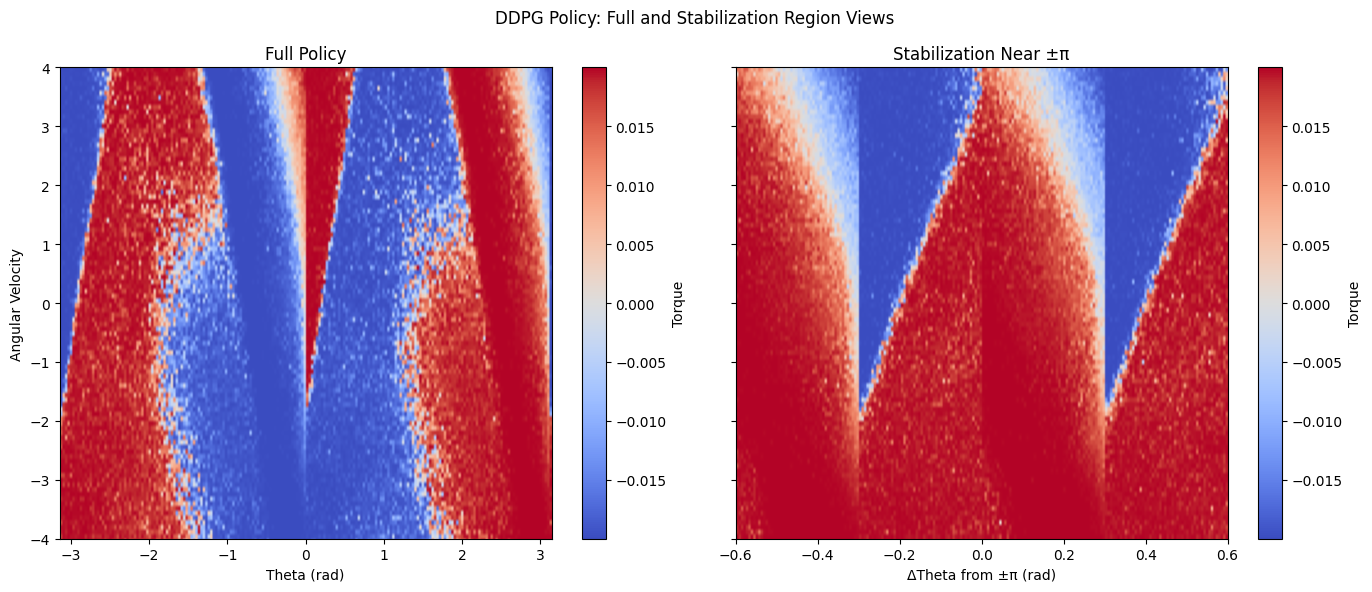

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_policy_with_stabilization_view(controller, 
                                             theta_range=(-np.pi, np.pi), 
                                             vel_range=(-8, 8), 
                                             stab_range=0.6,
                                             bins=200,
                                             zoom_bins=100):
    """
    Plots two heatmaps:
    1. Full (theta, velocity) policy
    2. Zoomed view around stabilization point ±π, shown as deviation from upright

    Parameters
    ----------
    controller : ddpg_controller
        The DDPG controller.
    theta_range : tuple
        Range for theta in full plot.
    vel_range : tuple
        Range for velocity in both plots.
    stab_range : float
        Maximum deviation (in radians) from the upright position (π or -π).
    bins : int
        Resolution for full plot.
    zoom_bins : int
        Resolution for zoom plot.
    """
    def compute_actions(theta_vals, vel_vals):
        actions = np.zeros((len(vel_vals), len(theta_vals)))
        for i, th in enumerate(theta_vals):
            for j, vel in enumerate(vel_vals):
                _, _, action = controller.get_control_output(meas_pos=th, meas_vel=vel)
                actions[j, i] = action
        return actions

    # === Full policy ===
    thetas = np.linspace(*theta_range, bins)
    vels = np.linspace(*vel_range, bins)
    full_actions = compute_actions(thetas, vels)

    # === Stabilization view around ±π ===
    delta_theta_vals = np.linspace(-stab_range, stab_range, zoom_bins)
    vels_zoom = np.linspace(-4, 4, zoom_bins)

    # Map delta_theta to wrapped angles near ±π
    theta_left = -np.pi + delta_theta_vals  # around -π
    theta_right = np.pi - delta_theta_vals  # around +π

    # Merge both into one batch
    theta_zoom = np.concatenate([theta_left, theta_right])
    delta_zoom = np.concatenate([delta_theta_vals, delta_theta_vals])  # for x-axis
    vels_zoom_full = np.tile(vels_zoom, 2)

    actions_zoom = np.zeros((zoom_bins, 2 * zoom_bins))
    for i, dt in enumerate(delta_theta_vals):
        for j, vel in enumerate(vels_zoom):
            _, _, a_left = controller.get_control_output(meas_pos=-np.pi + dt, meas_vel=vel)
            _, _, a_right = controller.get_control_output(meas_pos=np.pi + dt, meas_vel=vel)
            actions_zoom[j, i] = a_left
            actions_zoom[j, i + zoom_bins] = a_right

    # === Plotting ===
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Full plot
    im1 = axs[0].imshow(full_actions, extent=[*theta_range, *vel_range],
                        origin='lower', aspect='auto', cmap='coolwarm')
    axs[0].set_title("Full Policy")
    axs[0].set_xlabel("Theta (rad)")
    axs[0].set_ylabel("Angular Velocity")
    fig.colorbar(im1, ax=axs[0], label='Torque')

    # Stabilization plot
    x_extent = [-stab_range, stab_range]
    im2 = axs[1].imshow(actions_zoom, extent=[x_extent[0], x_extent[1], -4, 4],
                        origin='lower', aspect='auto', cmap='coolwarm')
    axs[1].set_title("Stabilization Near ±π")
    axs[1].set_xlabel("ΔTheta from ±π (rad)")
    fig.colorbar(im2, ax=axs[1], label='Torque')

    plt.suptitle("DDPG Policy: Full and Stabilization Region Views")
    plt.tight_layout()
    plt.show()
visualize_policy_with_stabilization_view(controller)

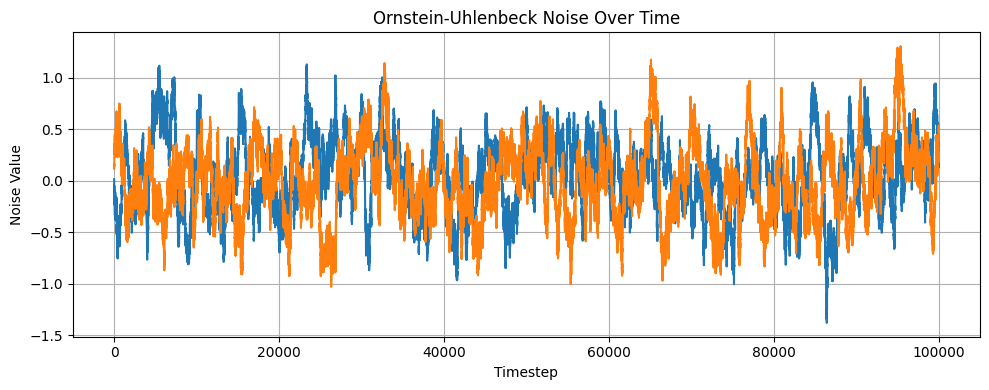

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Your OUActionNoise class
class OUActionNoise:
    def __init__(self, mean, std_deviation,
                 theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        x = (
            self.x_prev +
            self.theta * (self.mean - self.x_prev) * self.dt +
            self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

# Initialize noise generator
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=0.2)

# Generate noise over time


# Plot the noise
plt.figure(figsize=(10, 4))
for i in range(2):
    #ou_noise.reset()
    timesteps = 100_000
    noise = np.array([ou_noise() for _ in range(timesteps)])
    plt.plot(noise)
plt.title("Ornstein-Uhlenbeck Noise Over Time")
plt.xlabel("Timestep")
plt.ylabel("Noise Value")
plt.grid(True)
plt.tight_layout()
plt.show()


